In [1]:
#from __future__ import print_function
import yaml 
import torch
import numpy as np
import torch.utils.data
from torch import optim
from datetime import datetime
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os
import matplotlib.pyplot as plt 
import numpy as np
import time

from vae_svhn import*
from vae_mnist import*
from vae import*
from train_mmvae import*
from latent_regularizer import*
from moemmvae import*
from data_builder import*
from PairedRegionDataset import*
from PairedDoDataset import*

In [2]:
# config parameters
random_seed = 1
input_dim1 = 4842 # 5873  
input_dim2 = 4850 # 36  
H1_1 =  256 # 128
H2_1 = 128 # 64
H3_1 = 64 # 32
H1_2 = 256 # 35  
H2_2 = 128 # 16  
H3_2 = 64 # 10  
latent_dim = 20 # 10
epochs = 50
batch_size = 256 # 128
log_interval = 10
scale1 = 100 * latent_dim / (input_dim1) # 50 * latent_dim / (input_dim1)
scale2 = 100 * latent_dim / (input_dim2) # 50 * latent_dim / (input_dim2)
num_samples = 2
dataset_abbrev =  ['HC', 'PFC'] # ['Geno', 'Physio']
output_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/sampletest_singlegaussian_30perc'  # 'results_mmvae_domice5'
accelerator = True 
#input_path =  '/nfs/turbo/umms-adraelos/caloric_restriction_DO_mice/Genotype_data/joined_genetic_physio.csv'
input_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv'
dataset = 'AD'  # 'DO' or 'AD'

In [3]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [4]:
# load in dataset
paired_df = pd.read_csv(input_path, low_memory=False)
if dataset == 'AD':
    hc_cols = [col for col in paired_df.columns if col.endswith(dataset_abbrev[0])]
    hc_meta_cols = ['barcode_HC', 'subclass_HC', 'cell_type_HC', 'SCBID_HC', 'MouseID_HC', 'Age_HC', 'Genotype_HC', 'CFM_14_5_snRNA_HC', '14-6-residual_HC', '14-6-Bin_HC', 'strain']
    hc_data_cols = [col for col in hc_cols if col not in hc_meta_cols]
    pfc_cols = [col for col in paired_df.columns if col.endswith(dataset_abbrev[1])]
    pfc_meta_cols = ['barcode_PFC', 'subclass_PFC', 'cell_type_PFC', 'SCBID_PFC', 'MouseID_PFC', 'Age_PFC', 'Genotype_PFC', 'CFM_14_5_snRNA_PFC', '14-6-residual_PFC', '14-6-Bin_PFC', 'strain']
    pfc_data_cols = [col for col in pfc_cols if col not in pfc_meta_cols]
    train_dataset = PairedRegionDataset(paired_df, hc_data_cols, pfc_data_cols, hc_meta_cols, pfc_meta_cols, '14-6-Bin_HC', 'Strain')
    test_dataset = PairedRegionDataset(paired_df, hc_data_cols, pfc_data_cols, hc_meta_cols, pfc_meta_cols, '14-6-Bin_HC', 'Strain')
elif dataset == 'DO':
    genetic_dims = input_dim1 + 1
    diet_col = 'Diet'
    id_col = 'MouseID'
    label_col = 'Diet_num'
    train_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)
    test_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)

In [5]:
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [6]:
first_iter = next(iter(train_loader))

In [7]:
first_iter[1][0].shape

torch.Size([20, 4850])

In [8]:
first_iter[0][0].shape

torch.Size([20, 4842])

In [9]:
first_iter[0][0]

tensor([[ 0.6763, -0.6767,  0.0781,  ...,  2.1639, -0.6621, -0.5694],
        [ 0.1720,  0.9664,  0.4969,  ..., -0.9244, -1.2974, -0.7724],
        [ 0.1639,  0.4687, -0.9896,  ...,  0.8259, -0.3006, -1.3949],
        ...,
        [ 0.2987, -0.5043, -0.3088,  ...,  0.7951,  0.3534, -1.4814],
        [-1.0761,  0.3176, -0.8375,  ..., -0.7510, -0.3759,  1.6909],
        [-1.7206,  0.0301, -2.5801,  ..., -1.0901, -1.4141,  0.0746]])

In [10]:
torch.max(first_iter[0][0]), torch.min(first_iter[0][0])

(tensor(5.7443), tensor(-5.5798))

In [11]:
torch.max(first_iter[1][0]), torch.min(first_iter[1][0])

(tensor(5.6939), tensor(-5.4341))

In [12]:
# np.sort(paired_df.iloc[:, input_dim1+2:-2].values.flatten())[-4000:]

In [13]:
# initialize model and load in data 
model = MMVAE(input_dim1, input_dim2, H1_1, H2_1, H3_1, H1_2, H2_2, H3_2, latent_dim, scale1, scale2, learn_prior = False)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, amsgrad=True)

In [14]:
# train model 
total_loss = []
total_test_loss = []
test_epochs = []
individual_loss = {}
recon_loss = {}
for i, dataset in enumerate(dataset_abbrev): 
    individual_loss[dataset] = {}
    individual_loss[dataset]['lpx_z'] = []
    individual_loss[dataset]['kls'] = []
    recon_loss[dataset] = {}
    if i ==  0:
        recon_loss[dataset][dataset] = []
        recon_loss[dataset][dataset_abbrev[i+1]] = []
    else:
        recon_loss[dataset][dataset] = []
        recon_loss[dataset][dataset_abbrev[i-1]] = []

start_time = time.time()
for epoch in range(1, epochs+1):
    loss, lpx_zs, kls, lpxz_ind = train(epoch, model, optimizer, train_loader, num_samples, device, epochs)
    print('one iteration done')
    total_loss.append(loss)
    for i, dataset in enumerate(dataset_abbrev): 
        individual_loss[dataset]['lpx_z'].append(lpx_zs[i]) 
        individual_loss[dataset]['kls'].append(kls[i])
        if i ==  0:
            recon_loss[dataset][dataset].append(lpxz_ind[0] / len(train_loader))
            recon_loss[dataset][dataset_abbrev[i+1]].append(lpxz_ind[1] / len(train_loader))
        else:
            recon_loss[dataset][dataset].append(lpxz_ind[3] / len(train_loader))
            recon_loss[dataset][dataset_abbrev[i-1]].append(lpxz_ind[2] / len(train_loader))
    if epoch in [epochs / 2, epochs]:
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_samples, device, output_folder, dataset_abbrev)
end_time = time.time()
print(str(end_time - start_time) + ' seconds for training/testing')

====> Epoch: 001 Train loss: 564.6960
one iteration done
====> Epoch: 002 Train loss: 563.2514
one iteration done
====> Epoch: 003 Train loss: 561.9926
one iteration done
====> Epoch: 004 Train loss: 560.3404
one iteration done
====> Epoch: 005 Train loss: 558.1898
one iteration done
====> Epoch: 006 Train loss: 555.2488
one iteration done
====> Epoch: 007 Train loss: 551.8957
one iteration done
====> Epoch: 008 Train loss: 548.1897
one iteration done
====> Epoch: 009 Train loss: 546.5058
one iteration done
====> Epoch: 010 Train loss: 542.1654
one iteration done
====> Epoch: 011 Train loss: 539.8146
one iteration done
====> Epoch: 012 Train loss: 537.4611
one iteration done
====> Epoch: 013 Train loss: 533.7758
one iteration done
====> Epoch: 014 Train loss: 530.0939
one iteration done
====> Epoch: 015 Train loss: 527.3082
one iteration done
====> Epoch: 016 Train loss: 526.5097
one iteration done
====> Epoch: 017 Train loss: 522.9910
one iteration done
====> Epoch: 018 Train loss: 51

In [15]:
file = os.path.join(output_folder, 'train_times.txt')
with open(file, "a") as file:
    file.write('\n ' + str(datetime.now()) + ', ')
    file.write(str(epochs) + ' epochs, ')
    file.write(str(end_time - start_time) + ' seconds for training/testing')

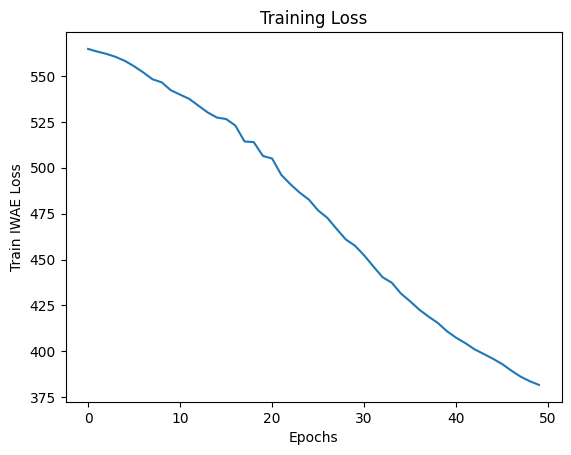

In [16]:
# plot training data 
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Train IWAE Loss')             
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

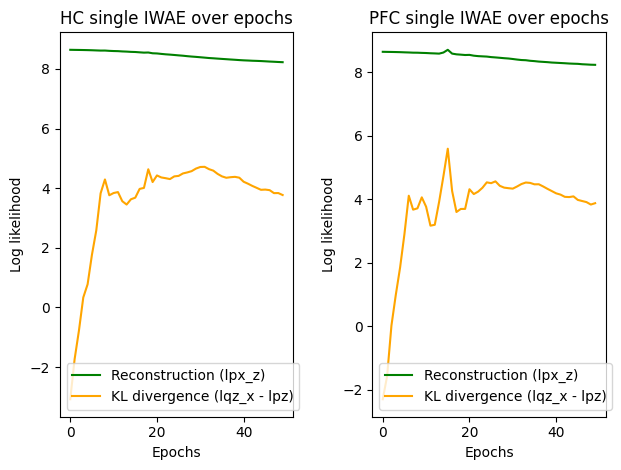

In [17]:
# plot individual loss functions from each encoder 
fig, ax = plt.subplots(1, 2)
for i, dataset in enumerate(dataset_abbrev):
    ax[i].plot(np.log(individual_loss[dataset]['lpx_z']), color='green', label='Reconstruction (lpx_z)')
    ax[i].plot(np.log(individual_loss[dataset]['kls']), color='orange', label='KL divergence (lqz_x - lpz)')
    ax[i].set_title(dataset + ' single IWAE over epochs')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log likelihood')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

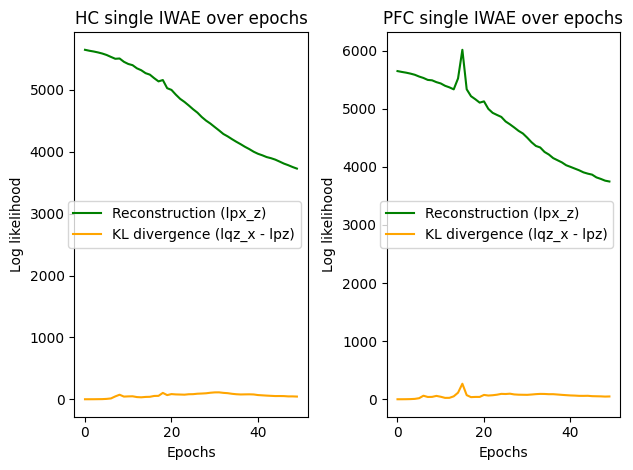

In [18]:
# plot individual loss functions from each encoder 
fig, ax = plt.subplots(1, 2)
for i, dataset in enumerate(dataset_abbrev):
    ax[i].plot((individual_loss[dataset]['lpx_z']), color='green', label='Reconstruction (lpx_z)')
    ax[i].plot((individual_loss[dataset]['kls']), color='orange', label='KL divergence (lqz_x - lpz)')
    ax[i].set_title(dataset + ' single IWAE over epochs')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log likelihood')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

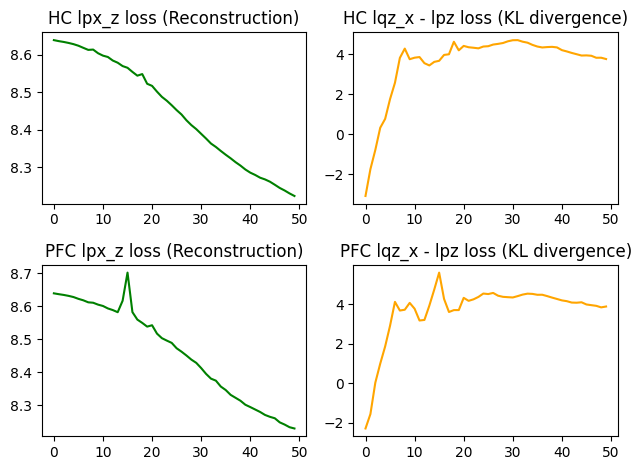

In [19]:
fig, ax = plt.subplots(2, 2)
for i, dataset in enumerate(dataset_abbrev):
    ax[i, 0].plot(np.log(individual_loss[dataset]['lpx_z']), color='green')
    ax[i, 0].set_title(dataset + ' lpx_z loss (Reconstruction)')
    ax[i, 1].plot(np.log(individual_loss[dataset]['kls']), color='orange')
    ax[i, 1].set_title(dataset + ' lqz_x - lpz loss (KL divergence)')
    plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_loss_graphs_log.png'))

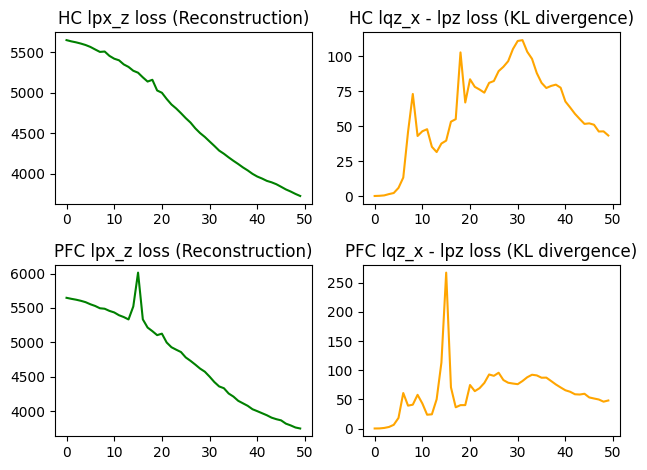

In [20]:
fig, ax = plt.subplots(2, 2)
for i, dataset in enumerate(dataset_abbrev):
    ax[i, 0].plot((individual_loss[dataset]['lpx_z']), color='green')
    ax[i, 0].set_title(dataset + ' lpx_z loss (Reconstruction)')
    ax[i, 1].plot((individual_loss[dataset]['kls']), color='orange')
    ax[i, 1].set_title(dataset + ' lqz_x - lpz loss (KL divergence)')
    plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_loss_graphs.png'))

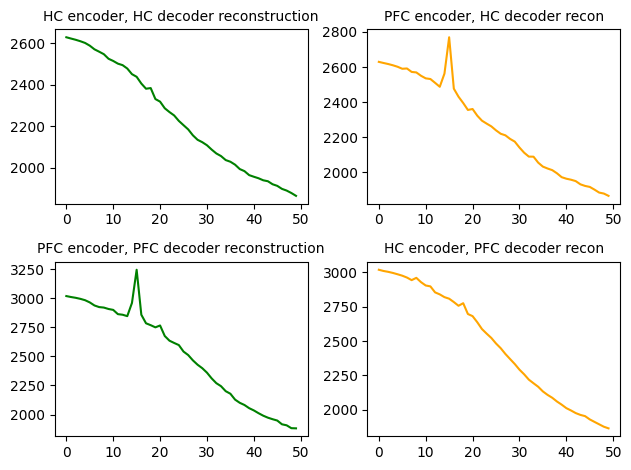

In [21]:
# Plotting each kind of reconstruction
fig, ax = plt.subplots(2, 2)
for i, dataset in enumerate(dataset_abbrev):
    ax[i, 0].plot((recon_loss[dataset][dataset]), color='green', label=f'{dataset} encoder')
    ax[i, 0].set_title(f'{dataset} encoder, {dataset} decoder reconstruction', fontsize=10)
    if i == 0:
        ax[i, 1].plot((recon_loss[dataset_abbrev[i+1]][dataset]), color='orange', label=f'{dataset_abbrev[i+1]} encoder')
        ax[i, 1].set_title(f'{dataset_abbrev[i+1]} encoder, {dataset} decoder recon', fontsize=10)
    else: 
        ax[i, 1].plot((recon_loss[dataset_abbrev[i-1]][dataset]), color='orange', label=f'{dataset_abbrev[i-1]} encoder')
        ax[i, 1].set_title(f'{dataset_abbrev[i-1]} encoder, {dataset} decoder recon', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))